# Full Pipeline Tutorial

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tlancaster6/AquaCal/blob/main/docs/tutorials/01_full_pipeline.ipynb)

This tutorial demonstrates the complete AquaCal calibration pipeline from start to finish. You'll learn how to:

- Load synthetic or real calibration data
- Run all four calibration stages (or load a previous calibration)
- Visualize camera rig geometry and calibration quality
- Diagnose calibration results with reprojection and 3D error analysis

**Prerequisites:** Basic Python and OpenCV knowledge. Familiarity with camera calibration concepts is helpful but not required.

In [14]:
# Colab setup installs AquaCal from PyPI if running on Google Colab.
# When running locally, this cell is a no-op.
import sys

if "google.colab" in sys.modules:
    print("Colab detected â€” installing AquaCal...")
    !pip install -q aquacal
    print("Done.")
else:
    print("Local environment â€” skipping install.")

Local environment â€” skipping install.


## Data Source Selection

Choose your data source:

- **`synthetic-small`** (recommended for first run): 4 cameras, 20 frames, ideal conditions (no noise). Fast, no download required. Uses the same "ideal" scenario as the small preset in the [synthetic validation tutorial](02_synthetic_validation.ipynb).
- **`synthetic-large`**: 12 cameras matching the real hardware rig, 30 frames, 0.5 px noise. Slower but produces compelling diagnostics. Uses the same "realistic" scenario as the large preset in the [synthetic validation tutorial](02_synthetic_validation.ipynb).
- **`zenodo`**: Downloads a real hardware dataset from Zenodo (~164 MB, 13 cameras) and runs the full calibration pipeline from scratch. A reference calibration is included for comparison but is not used. Requires internet on first run. Note that your calibration will probably be worse than the reference calibration, as the zenodo dataset only contains a few calibration images per camera. 

In [2]:
DATA_SOURCE = "zenodo"  # Options: "synthetic-small", "synthetic-large", "zenodo" 

## Setup and Imports

We'll import the necessary modules and configure matplotlib for inline plotting.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from aquacal.calibration import calibrate_from_detections
from aquacal.core.board import BoardGeometry
from aquacal.datasets import create_scenario, generate_synthetic_detections, load_example
from aquacal.validation.diagnostics import plot_camera_rig, plot_per_camera_error, plot_error_distribution
from aquacal.validation.reprojection import compute_reprojection_errors

# Configure matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

OUTPUT_DIR = Path("output")

print("Imports complete!")

Imports complete!


## Load Data and Calibrate

This cell loads data and produces a `CalibrationResult` â€” the central object for all
subsequent analysis. The path differs by data source:

- **Synthetic**: generate a scenario with `create_scenario()`, produce detections, run Stages 2-3
- **Zenodo (real rig)**: download the dataset and run the complete pipeline (Stages 1-4, ~15-20 min)

In [4]:
# These will be set by the data-source branch below:
#   result     â€” CalibrationResult (always)
#   scenario   â€” SyntheticScenario with ground truth (synthetic only, else None)
#   detections â€” DetectionResult (synthetic only, else None)
#   board      â€” BoardGeometry (always)

scenario = None
detections = None
board_poses = None
reprojection_result = None
pipeline_output_dir = None

if DATA_SOURCE in ("synthetic-small", "synthetic-large"):
    # --- Create scenario ---
    # "synthetic-small" uses create_scenario("ideal"):  4 cameras, 20 frames, 0 noise
    # "synthetic-large" uses create_scenario("realistic"): 12 cameras, 30 frames, 0.5px noise
    scenario_name = "ideal" if DATA_SOURCE == "synthetic-small" else "realistic"
    scenario = create_scenario(scenario_name, seed=42)
    print(f"Created scenario: {scenario.description}")
    print(f"  Cameras: {len(scenario.intrinsics)}, Frames: {len(scenario.board_poses)}, Noise: {scenario.noise_std} px")

    board = BoardGeometry(scenario.board_config)

    # --- Generate detections ---
    print("Generating synthetic detections...")
    detections = generate_synthetic_detections(
        intrinsics=scenario.intrinsics,
        extrinsics=scenario.extrinsics,
        water_zs=scenario.water_zs,
        board=board,
        board_poses=scenario.board_poses,
        noise_std=scenario.noise_std,
        seed=42,
    )

    # --- Run Stages 2-3 ---
    print("Running calibration (Stages 2-3)...")
    result, board_poses = calibrate_from_detections(
        detections, scenario.intrinsics, board,
    )

    # Compute detailed reprojection errors for later analysis
    reprojection_result = compute_reprojection_errors(result, detections, board_poses)
    print(f"\nCalibration complete!  RMS: {result.diagnostics.reprojection_error_rms:.3f} px")

elif DATA_SOURCE == "zenodo":
    import os
    from aquacal.calibration.pipeline import run_calibration

    print("Downloading real-rig dataset from Zenodo (first run only)...")
    dataset = load_example("real-rig")
    config_path = dataset.cache_path / "config.yaml"

    # chdir so relative paths in config.yaml resolve correctly
    original_cwd = os.getcwd()
    os.chdir(dataset.cache_path)

    print("Running full calibration pipeline (Stages 1-4, ~15-20 min)...")
    result = run_calibration(str(config_path), verbose=True)

    os.chdir(original_cwd)

    pipeline_output_dir = dataset.cache_path / "output"
    board = BoardGeometry(result.board)
    print(f"\nCalibration complete!")
    print(f"  Cameras: {len(result.cameras)}")
    print(f"  RMS: {result.diagnostics.reprojection_error_rms:.3f} px")
    print(f"  3D error: {result.diagnostics.validation_3d_error_mean * 1000:.2f} mm (mean)")

else:
    raise ValueError(f"Unknown DATA_SOURCE: {DATA_SOURCE!r}")

Running full calibration pipeline (Stages 1-4, ~15-20 min)...
AquaCal Calibration Pipeline

[Stage 1] Intrinsic calibration (in-air)...
  Calibrating e3v8250 (1/13)...
  Calibrating e3v829d (2/13)...
  Calibrating e3v82e0 (3/13)...
  Calibrating e3v82f9 (4/13)...
  Calibrating e3v831e (5/13)...
  Calibrating e3v832e (6/13)...
  Calibrating e3v8334 (7/13)...
  Calibrating e3v83e9 (8/13)...
  Calibrating e3v83eb (9/13)...
  Calibrating e3v83ee (10/13)...
  Calibrating e3v83ef (11/13)...
  Calibrating e3v83f0 (12/13)...
  Calibrating e3v83f1 (13/13)...
  e3v8250: RMS 0.503 px
  e3v829d: RMS 0.376 px
  e3v82e0: RMS 0.479 px
  e3v82f9: RMS 0.276 px
  e3v831e: RMS 0.570 px
  e3v832e: RMS 0.470 px
  e3v8334: RMS 0.386 px
  e3v83e9: RMS 0.420 px
  e3v83eb: RMS 0.477 px
  e3v83ee: RMS 0.346 px
  e3v83ef: RMS 0.388 px
  e3v83f0: RMS 0.397 px
  e3v83f1: RMS 0.474 px
  Calibrated 13 cameras

[Detection] Detecting ChArUco in underwater videos...
  Frame 6/60 (10%)
  Frame 12/60 (20%)
  Frame 18/60 

## Exploring the Result

Every calibration produces a `CalibrationResult` containing per-camera parameters,
interface geometry, and diagnostic metrics.

In [5]:
cam_names_sorted = sorted(result.cameras.keys())
print(f"Cameras ({len(cam_names_sorted)}): {cam_names_sorted}")

print(f"\nBoard: {result.board.squares_x}x{result.board.squares_y}, "
      f"{result.board.square_size * 1000:.1f} mm squares")

print(f"\nInterface: n_air={result.interface.n_air}, n_water={result.interface.n_water}")

print(f"\nDiagnostics:")
print(f"  Reprojection RMS: {result.diagnostics.reprojection_error_rms:.3f} px")
if result.diagnostics.validation_3d_error_mean > 0:
    print(f"  3D error mean:    {result.diagnostics.validation_3d_error_mean * 1000:.2f} mm")
    print(f"  3D error std:     {result.diagnostics.validation_3d_error_std * 1000:.2f} mm")

print(f"\nWater surface Z per camera:")
for cam in cam_names_sorted:
    cc = result.cameras[cam]
    C = cc.extrinsics.C
    h_c = cc.water_z - C[2]
    print(f"  {cam}: water_z = {cc.water_z:.4f} m, "
          f"C = [{C[0]:.3f}, {C[1]:.3f}, {C[2]:.3f}], h_c = {h_c:.4f} m")

Cameras (13): ['e3v8250', 'e3v829d', 'e3v82e0', 'e3v82f9', 'e3v831e', 'e3v832e', 'e3v8334', 'e3v83e9', 'e3v83eb', 'e3v83ee', 'e3v83ef', 'e3v83f0', 'e3v83f1']

Board: 12x9, 60.0 mm squares

Interface: n_air=1.0, n_water=1.333

Diagnostics:
  Reprojection RMS: 0.934 px
  3D error mean:    0.24 mm
  3D error std:     0.37 mm

Water surface Z per camera:
  e3v8250: water_z = 1.0197 m, C = [-0.334, 0.576, 0.015], h_c = 1.0046 m
  e3v829d: water_z = 1.0197 m, C = [0.000, 0.000, 0.000], h_c = 1.0197 m
  e3v82e0: water_z = 1.0197 m, C = [-0.334, -0.060, -0.012], h_c = 1.0314 m
  e3v82f9: water_z = 1.0197 m, C = [0.344, 0.568, -0.004], h_c = 1.0240 m
  e3v831e: water_z = 1.0197 m, C = [-0.889, 0.280, -0.016], h_c = 1.0362 m
  e3v832e: water_z = 1.0197 m, C = [0.210, 0.238, 0.008], h_c = 1.0112 m
  e3v8334: water_z = 1.0197 m, C = [-0.659, 0.007, 0.002], h_c = 1.0181 m
  e3v83e9: water_z = 1.0197 m, C = [-0.330, 1.197, 0.031], h_c = 0.9892 m
  e3v83eb: water_z = 1.0197 m, C = [-0.876, 0.887, 0.0

## Camera Rig Geometry

A 3D plot of the camera positions and orientations from the calibration result.
The water surface plane is shown at the estimated Z-coordinate.

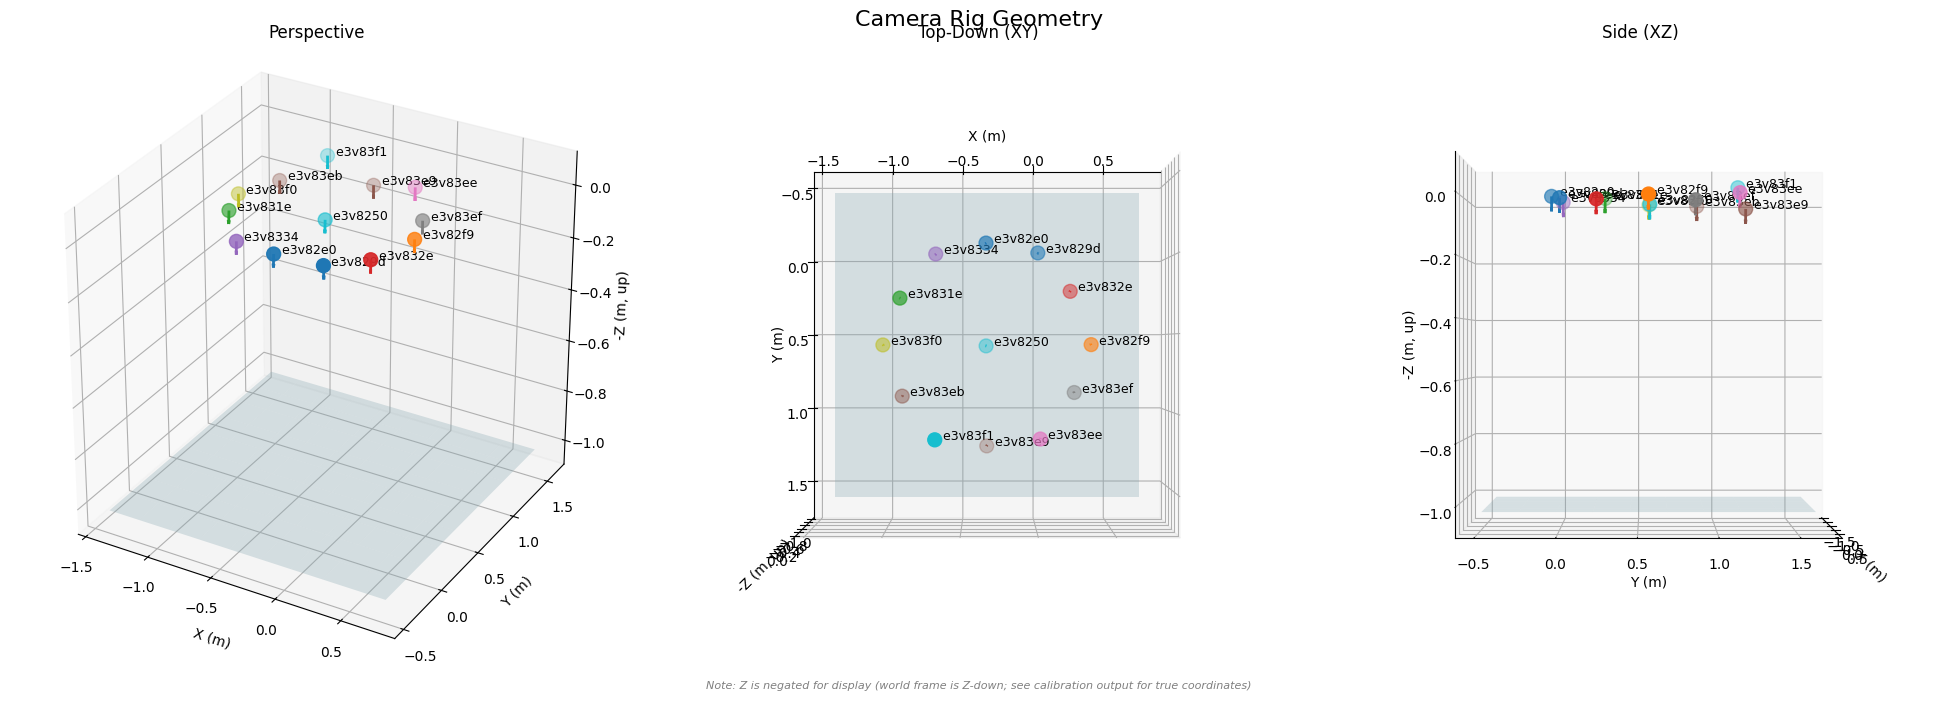

In [6]:
%matplotlib inline
fig = plot_camera_rig(result, title="Camera Rig Geometry")
plt.show()
plt.close()

## Intrinsic Parameters

Focal lengths and principal points for each camera. For synthetic data these are
ground truth values passed through to calibration; for real data they come from
Stage 1 (in-air) calibration.

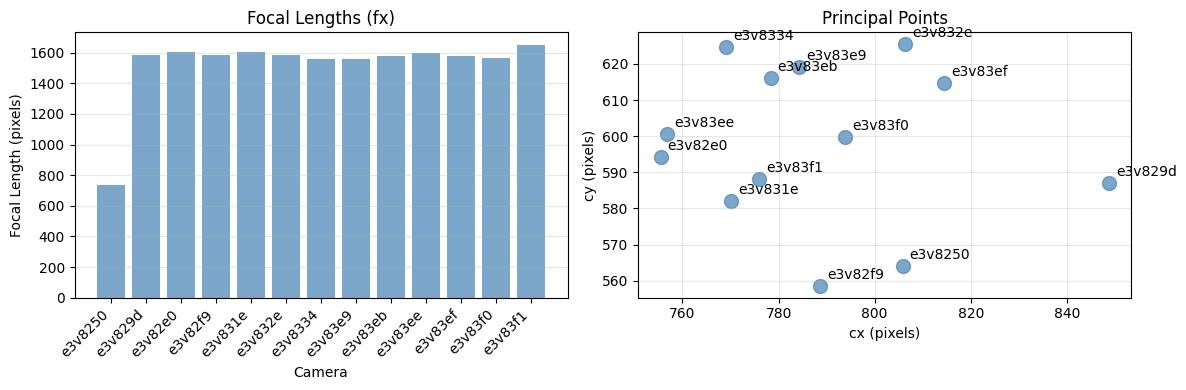

In [7]:
def plot_intrinsics_summary(result):
    """Side-by-side focal length bar chart and principal point scatter."""
    cam_names = sorted(result.cameras.keys())
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    fx_vals = [result.cameras[c].intrinsics.K[0, 0] for c in cam_names]
    cx_vals = [result.cameras[c].intrinsics.K[0, 2] for c in cam_names]
    cy_vals = [result.cameras[c].intrinsics.K[1, 2] for c in cam_names]

    x = np.arange(len(cam_names))
    ax1.bar(x, fx_vals, color='steelblue', alpha=0.7)
    ax1.set_xlabel('Camera')
    ax1.set_ylabel('Focal Length (pixels)')
    ax1.set_title('Focal Lengths (fx)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(cam_names, rotation=45, ha='right')
    ax1.grid(axis='y', alpha=0.3)

    ax2.scatter(cx_vals, cy_vals, s=100, color='steelblue', alpha=0.7)
    for i, cam in enumerate(cam_names):
        ax2.annotate(cam, (cx_vals[i], cy_vals[i]), xytext=(5, 5), textcoords='offset points')
    ax2.set_xlabel('cx (pixels)')
    ax2.set_ylabel('cy (pixels)')
    ax2.set_title('Principal Points')
    ax2.grid(alpha=0.3)

    fig.tight_layout()
    return fig

fig = plot_intrinsics_summary(result)
plt.show()
plt.close()

## Diagnostics

### Per-Camera Reprojection Error

A bar chart of per-camera RMS errors quickly reveals whether any camera is performing
worse than the others. Cameras with high error often have poor intrinsic calibration
or insufficient board observations.

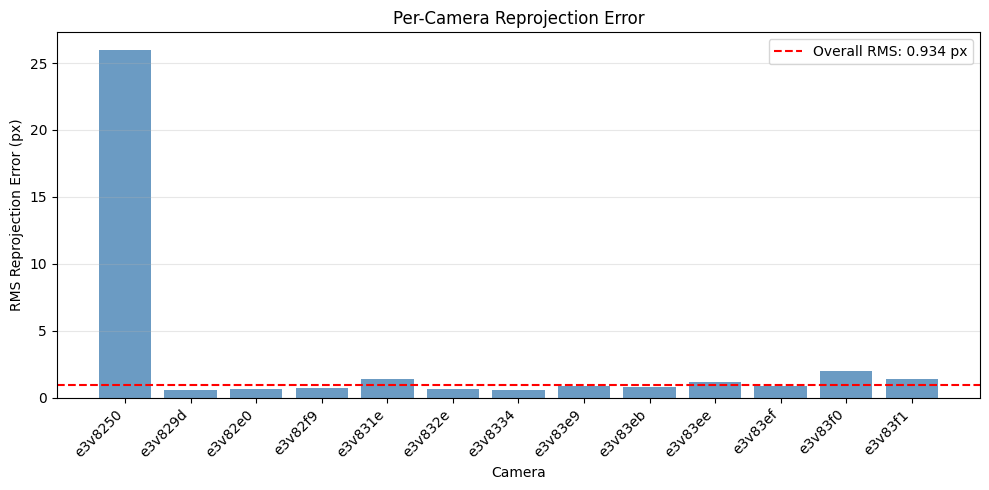

Cameras with error > 2x the average may need re-calibration.


In [8]:
fig = plot_per_camera_error(result)
plt.show()
plt.close()

print("Cameras with error > 2x the average may need re-calibration.")

### Reprojection Error Distribution

The histogram shows the overall distribution of per-corner errors across all cameras
and frames. A well-calibrated rig produces a tight distribution centered near zero.

For synthetic data, residuals come from recomputing projections against detections.
For the Zenodo dataset, residuals are loaded from the saved calibration file
(computed on the validation holdout set during the original pipeline run).

Error statistics:
  Primary cameras:
    N:               4,451
    Mean:            0.700 px
    Median:          0.563 px
    95th percentile: 1.642 px
    Max:             13.175 px
  Auxiliary cameras:
    N:               908
    Mean:            17.718 px
    Median:          10.700 px
    95th percentile: 58.351 px
    Max:             97.466 px


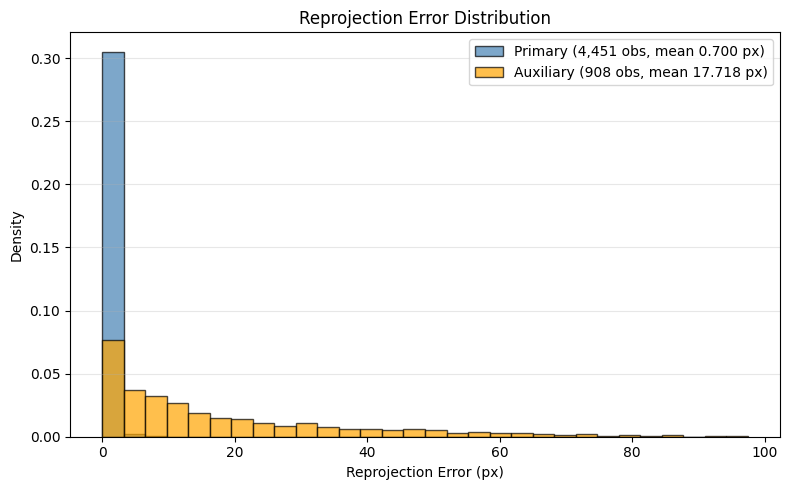

In [9]:
# Identify auxiliary cameras (if any) for split display
aux_cameras = {name for name, cc in result.cameras.items() if cc.is_auxiliary}

if reprojection_result is not None:
    fig = plot_error_distribution(reprojection_result, auxiliary_cameras=aux_cameras or None)
    plt.show()
    plt.close()
elif result.diagnostics.per_corner_residuals is not None:
    # Build a ReprojectionErrors from the saved residuals (e.g. Zenodo reference calibration)
    from aquacal.validation.reprojection import ReprojectionErrors

    camera_labels = (
        np.array(result.diagnostics.per_corner_camera_labels, dtype=object)
        if result.diagnostics.per_corner_camera_labels is not None
        else None
    )
    stored = ReprojectionErrors(
        rms=result.diagnostics.reprojection_error_rms,
        per_camera=result.diagnostics.reprojection_error_per_camera,
        per_frame=result.diagnostics.per_frame_errors or {},
        residuals=result.diagnostics.per_corner_residuals,
        num_observations=len(result.diagnostics.per_corner_residuals),
        camera_labels=camera_labels,
    )
    fig = plot_error_distribution(stored, auxiliary_cameras=aux_cameras or None)
    plt.show()
    plt.close()
else:
    print("Skipped â€” per-corner residuals not available for this data source.")
    print(f"Overall RMS from calibration: {result.diagnostics.reprojection_error_rms:.3f} px")

### Interface Distance Recovery (Synthetic Only)

The water surface Z-coordinate (`water_z`) is the key refractive parameter.
Comparing estimated values to ground truth tells you how well Stage 3 converged.

In [10]:
def plot_interface_recovery(result, scenario):
    """Grouped bar chart comparing estimated vs ground-truth water_z."""
    cam_names = sorted(result.cameras.keys())
    estimated = [result.cameras[c].water_z for c in cam_names]
    ground_truth = [scenario.water_zs[c] for c in cam_names]

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(cam_names))
    width = 0.35

    ax.bar(x - width / 2, estimated, width, label='Estimated', color='steelblue', alpha=0.8)
    ax.bar(x + width / 2, ground_truth, width, label='Ground Truth', color='orange', alpha=0.8)

    ax.set_xlabel('Camera')
    ax.set_ylabel('Interface Distance (m)')
    ax.set_title('Interface Distance Recovery')
    ax.set_xticks(x)
    ax.set_xticklabels(cam_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()

    mean_err = np.mean([abs(e - g) for e, g in zip(estimated, ground_truth)])
    print(f"Mean absolute interface distance error: {mean_err * 1000:.2f} mm")
    return fig

if scenario is not None:
    fig = plot_interface_recovery(result, scenario)
    plt.show()
    plt.close()
else:
    print("Skipped â€” ground truth not available for real data.")
    print("Estimated water_z values are shown in the result summary above.")

Skipped â€” ground truth not available for real data.
Estimated water_z values are shown in the result summary above.


### 3D Reconstruction Error

Reprojection error measures 2D fit quality, but 3D reconstruction error is the ultimate
accuracy metric. We triangulate board corners from multiple cameras and compare the
recovered inter-corner distances to the known board geometry.

3D Reconstruction Quality (from pipeline spatial measurements):
  Signed mean error: 0.006 mm
  RMSE:              0.441 mm
  Measurements:      1817


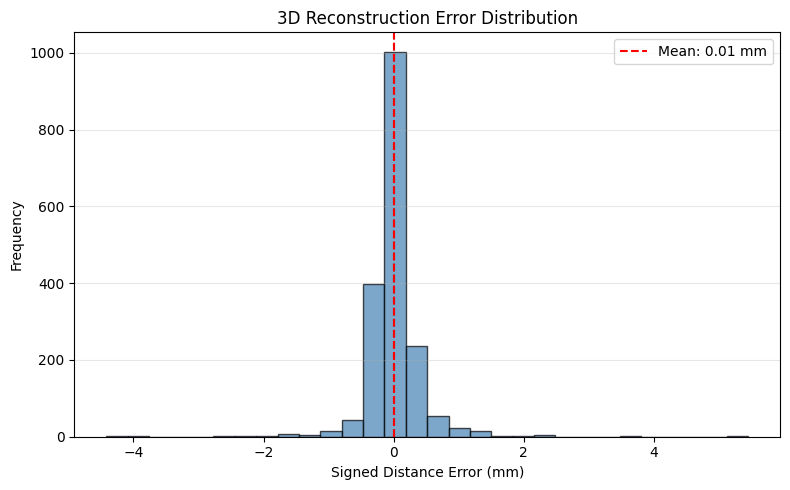

In [11]:
spatial_measurements = None

if detections is not None:
    from aquacal.validation.reconstruction import compute_3d_distance_errors

    dist_errors = compute_3d_distance_errors(
        calibration=result,
        detections=detections,
        board=board,
        include_per_pair=False,
        include_spatial=True,
    )

    print("3D Reconstruction Quality:")
    print(f"  Signed mean error: {dist_errors.signed_mean * 1000:.3f} mm")
    print(f"  RMSE:              {dist_errors.rmse * 1000:.3f} mm")
    print(f"  Comparisons:       {dist_errors.num_comparisons}")

    if dist_errors.spatial is not None:
        spatial_measurements = dist_errors.spatial
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.hist(
            spatial_measurements.signed_errors * 1000,
            bins=30, color='steelblue', alpha=0.7, edgecolor='black',
        )
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.axvline(
            dist_errors.signed_mean * 1000, color='red', linestyle='--',
            label=f'Mean: {dist_errors.signed_mean * 1000:.2f} mm',
        )
        ax.set_xlabel('Signed Distance Error (mm)')
        ax.set_ylabel('Frequency')
        ax.set_title('3D Reconstruction Error Distribution')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
        plt.close()

elif pipeline_output_dir is not None:
    spatial_csv = pipeline_output_dir / "spatial_measurements.csv"
    if spatial_csv.exists():
        from aquacal.validation.reconstruction import load_spatial_measurements

        spatial_measurements = load_spatial_measurements(spatial_csv)
        print("3D Reconstruction Quality (from pipeline spatial measurements):")
        print(f"  Signed mean error: {np.mean(spatial_measurements.signed_errors) * 1000:.3f} mm")
        print(f"  RMSE:              {np.sqrt(np.mean(spatial_measurements.signed_errors**2)) * 1000:.3f} mm")
        print(f"  Measurements:      {len(spatial_measurements.signed_errors)}")

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.hist(
            spatial_measurements.signed_errors * 1000,
            bins=30, color='steelblue', alpha=0.7, edgecolor='black',
        )
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        mean_err = np.mean(spatial_measurements.signed_errors) * 1000
        ax.axvline(
            mean_err, color='red', linestyle='--',
            label=f'Mean: {mean_err:.2f} mm',
        )
        ax.set_xlabel('Signed Distance Error (mm)')
        ax.set_ylabel('Frequency')
        ax.set_title('3D Reconstruction Error Distribution')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
        plt.close()
    else:
        print("3D Reconstruction Quality (from calibration diagnostics):")
        print(f"  Mean error: {result.diagnostics.validation_3d_error_mean * 1000:.2f} mm")
        print(f"  Std:        {result.diagnostics.validation_3d_error_std * 1000:.2f} mm")
        print(f"  (spatial_measurements.csv not found â€” histogram not available)")
else:
    print("3D Reconstruction Quality (from calibration diagnostics):")
    print(f"  Mean error: {result.diagnostics.validation_3d_error_mean * 1000:.2f} mm")
    print(f"  Std:        {result.diagnostics.validation_3d_error_std * 1000:.2f} mm")

### Common Issues Checklist

| Symptom | Likely Cause | Fix |
|---------|-------------|-----|
| High error for one camera | Poor intrinsic calibration | Re-calibrate intrinsics with more frames, check for motion blur |
| High error in image corners | Distortion model insufficient | Try rational model (8 coefficients) |
| Interface distance not converging | Initial estimate too far from truth | Provide better `initial_water_zs` in config |
| Interface distances differ between cameras | Degenerate board poses | Ensure board is visible at varied angles and depths |
| High 3D reconstruction error | Systematic bias | Check that `n_water` is correct for your water type |
| Reprojection < 1px but 3D error high | Overfitting to 2D | Verify interface distance initialization, add validation frames |

## Saving and Loading Results

AquaCal provides utilities to save and load calibration results in JSON format.

In [12]:
# Save calibration result
# save_calibration(result, "output/calibration.json")

# Load it back later
# loaded = load_calibration("output/calibration.json")

print("Calibration results can be saved to JSON for later use.")
print("See aquacal.io.serialization.save_calibration() and load_calibration().")

Calibration results can be saved to JSON for later use.
See aquacal.io.serialization.save_calibration() and load_calibration().


## Exported Data

The CSVs below capture the data behind all plots in this notebook, so downstream
consumers can reproduce figures without re-running the calibration.

In [13]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
cam_names = sorted(result.cameras.keys())

# --- Camera parameters (backs rig geometry, intrinsics, and interface plots) ---
rows_cameras = []
for cam in cam_names:
    cc = result.cameras[cam]
    C = cc.extrinsics.C
    K = cc.intrinsics.K
    rows_cameras.append({
        "camera": cam,
        "x_m": C[0], "y_m": C[1], "z_m": C[2],
        "fx_px": K[0, 0], "fy_px": K[1, 1],
        "cx_px": K[0, 2], "cy_px": K[1, 2],
        "water_z_m": cc.water_z,
        "h_c_m": cc.water_z - C[2],
        "reprojection_rms_px": result.diagnostics.reprojection_error_per_camera.get(cam, float("nan")),
    })
    # Add ground-truth water_z if available
    if scenario is not None:
        rows_cameras[-1]["gt_water_z_m"] = scenario.water_zs[cam]

df_cameras = pd.DataFrame(rows_cameras)
path_cameras = OUTPUT_DIR / "camera_parameters.csv"
df_cameras.to_csv(path_cameras, index=False)
print(f"Wrote {path_cameras}  ({len(df_cameras)} rows)")

# --- Reprojection residuals (backs error distribution histogram) ---
# Available from live computation (synthetic) or saved calibration (Zenodo)
residuals_array = None
camera_labels = None
if reprojection_result is not None:
    residuals_array = reprojection_result.residuals
    camera_labels = reprojection_result.camera_labels
elif result.diagnostics.per_corner_residuals is not None:
    residuals_array = result.diagnostics.per_corner_residuals
    if result.diagnostics.per_corner_camera_labels is not None:
        camera_labels = np.array(result.diagnostics.per_corner_camera_labels, dtype=object)

if residuals_array is not None:
    df_dict = {
        "residual_x_px": residuals_array[:, 0],
        "residual_y_px": residuals_array[:, 1],
    }
    if camera_labels is not None and len(camera_labels) == len(residuals_array):
        aux_set = {name for name, cc in result.cameras.items() if cc.is_auxiliary}
        df_dict["camera"] = camera_labels
        df_dict["is_auxiliary"] = [lbl in aux_set for lbl in camera_labels]
    df_residuals = pd.DataFrame(df_dict)
    path_residuals = OUTPUT_DIR / "reprojection_residuals.csv"
    df_residuals.to_csv(path_residuals, index=False)
    print(f"Wrote {path_residuals}  ({len(df_residuals)} rows)")

# --- 3D reconstruction errors (backs error histogram) ---
if spatial_measurements is not None:
    df_3d = pd.DataFrame({
        "x_m": spatial_measurements.positions[:, 0],
        "y_m": spatial_measurements.positions[:, 1],
        "z_m": spatial_measurements.positions[:, 2],
        "signed_error_m": spatial_measurements.signed_errors,
        "frame_idx": spatial_measurements.frame_indices,
    })
    path_3d = OUTPUT_DIR / "reconstruction_errors.csv"
    df_3d.to_csv(path_3d, index=False)
    print(f"Wrote {path_3d}  ({len(df_3d)} rows)")

Wrote output\camera_parameters.csv  (13 rows)
Wrote output\reprojection_residuals.csv  (5359 rows)
Wrote output\reconstruction_errors.csv  (1817 rows)


## Summary

In this tutorial you learned how to:

1. Load calibration data (synthetic or real hardware from Zenodo)
2. Run the calibration pipeline (Stages 2-3 for synthetic, Stages 1-4 for real data)
3. Inspect camera rig geometry, intrinsic parameters, and interface distances
4. Diagnose calibration quality with per-camera, distribution, and 3D error analysis
5. Save and load calibration results

**Next:** Explore [why refractive calibration matters](02_synthetic_validation.ipynb) with
controlled experiments comparing refractive vs non-refractive models.

- [User Guide](../guide/index.md): Comprehensive documentation on calibration theory and best practices